In [2]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_style("whitegrid")

In [6]:
# Cell 2: Load data + basic info
df = pd.read_csv(r"C:\Users\admin\Downloads\combined cycle powerplant (2).csv")   # <-- update path if needed

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (9568, 5)

Head:
    Ambient Temperature  Vacuum  Ambient Pressure  Relative Humidity  \
0                 8.34   40.77           1010.84              90.01   
1                23.64   58.49           1011.40              74.20   
2                29.74   56.90           1007.15              41.91   
3                19.07   49.69           1007.22              76.79   
4                11.80   40.66           1017.13              97.20   

   Electrical Power Output  
0                   480.48  
1                   445.75  
2                   438.76  
3                   453.09  
4                   464.43  

Dtypes:
 Ambient Temperature        float64
Vacuum                     float64
Ambient Pressure           float64
Relative Humidity          float64
Electrical Power Output    float64
dtype: object

Missing values:
 Ambient Temperature        0
Vacuum                     0
Ambient Pressure           0
Relative Humidity          0
Electrical Power Output    0
dtype: int64

In [7]:
# Cell 3: Clean data — nulls + IQR outlier removal
target_col = "Electrical Power Output"
feature_cols = ["Ambient Temperature", "Vacuum", "Ambient Pressure", "Relative Humidity"]

print("Rows before cleaning:", df.shape[0])

# Handle nulls
df = df.dropna()
print("Rows after dropping nulls:", df.shape[0])

# IQR-based outlier removal
def remove_outliers_iqr(data, cols):
    data = data.copy()
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

rows_before = df.shape[0]
df = remove_outliers_iqr(df, feature_cols + [target_col])
rows_after = df.shape[0]

print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

df = df.reset_index(drop=True)

Rows before cleaning: 9568
Rows after dropping nulls: 9568
Rows before outlier removal: 9568
Rows after outlier removal: 9470
Rows removed: 98


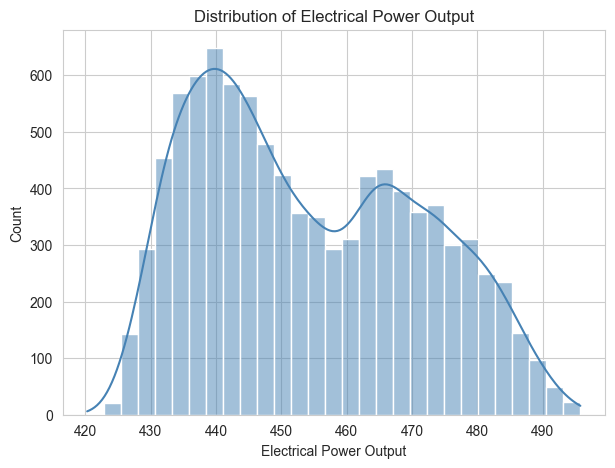

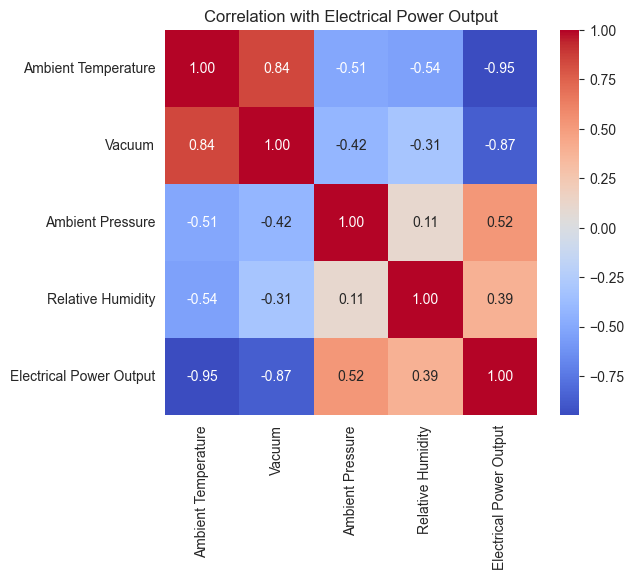

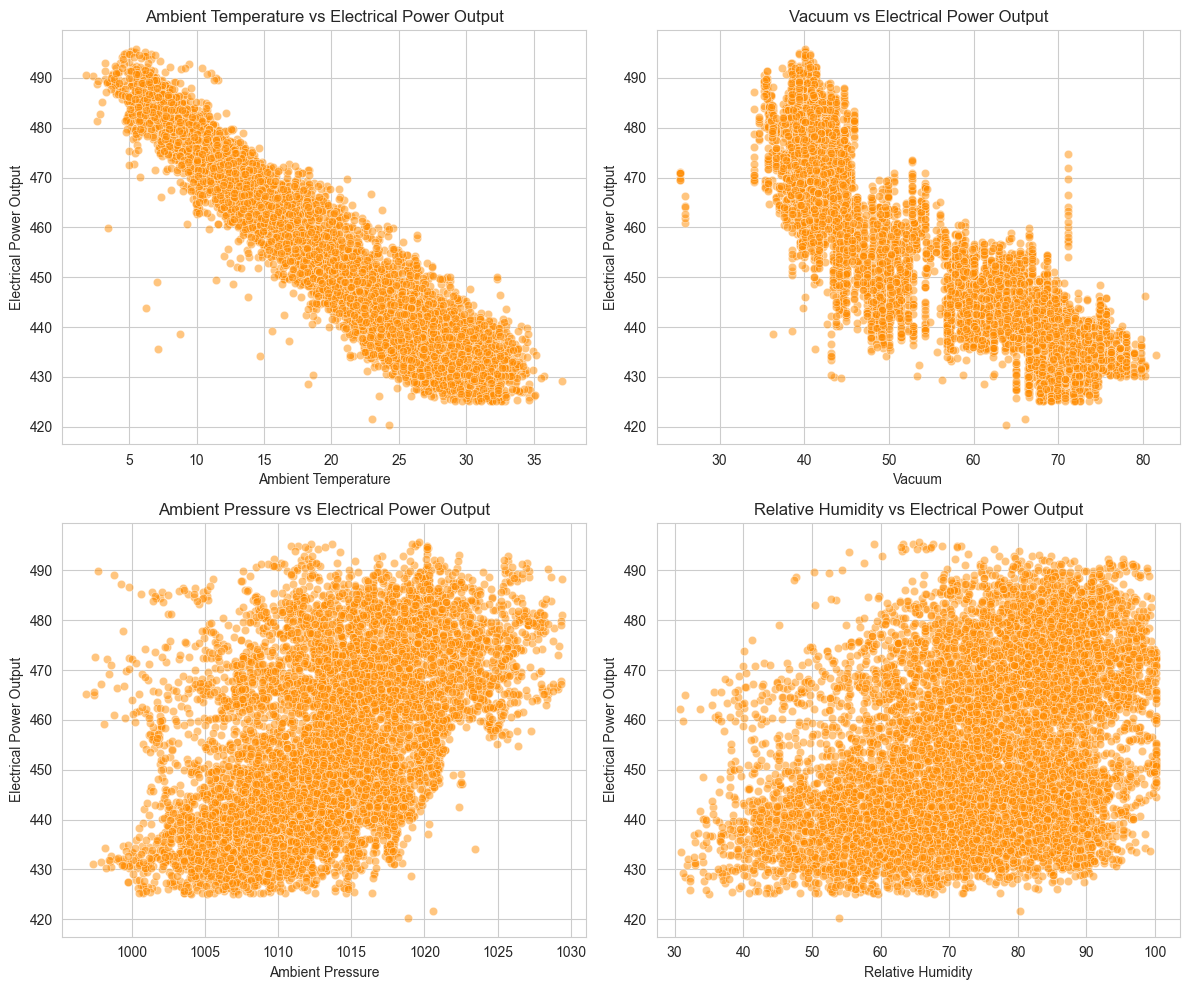

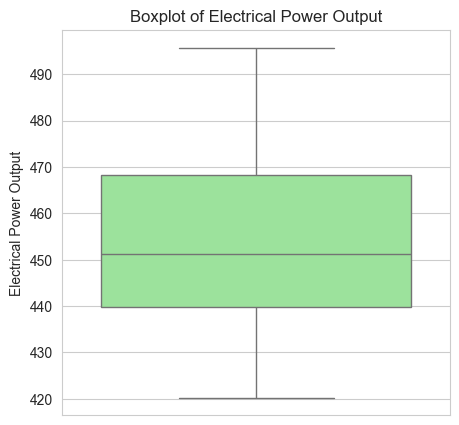

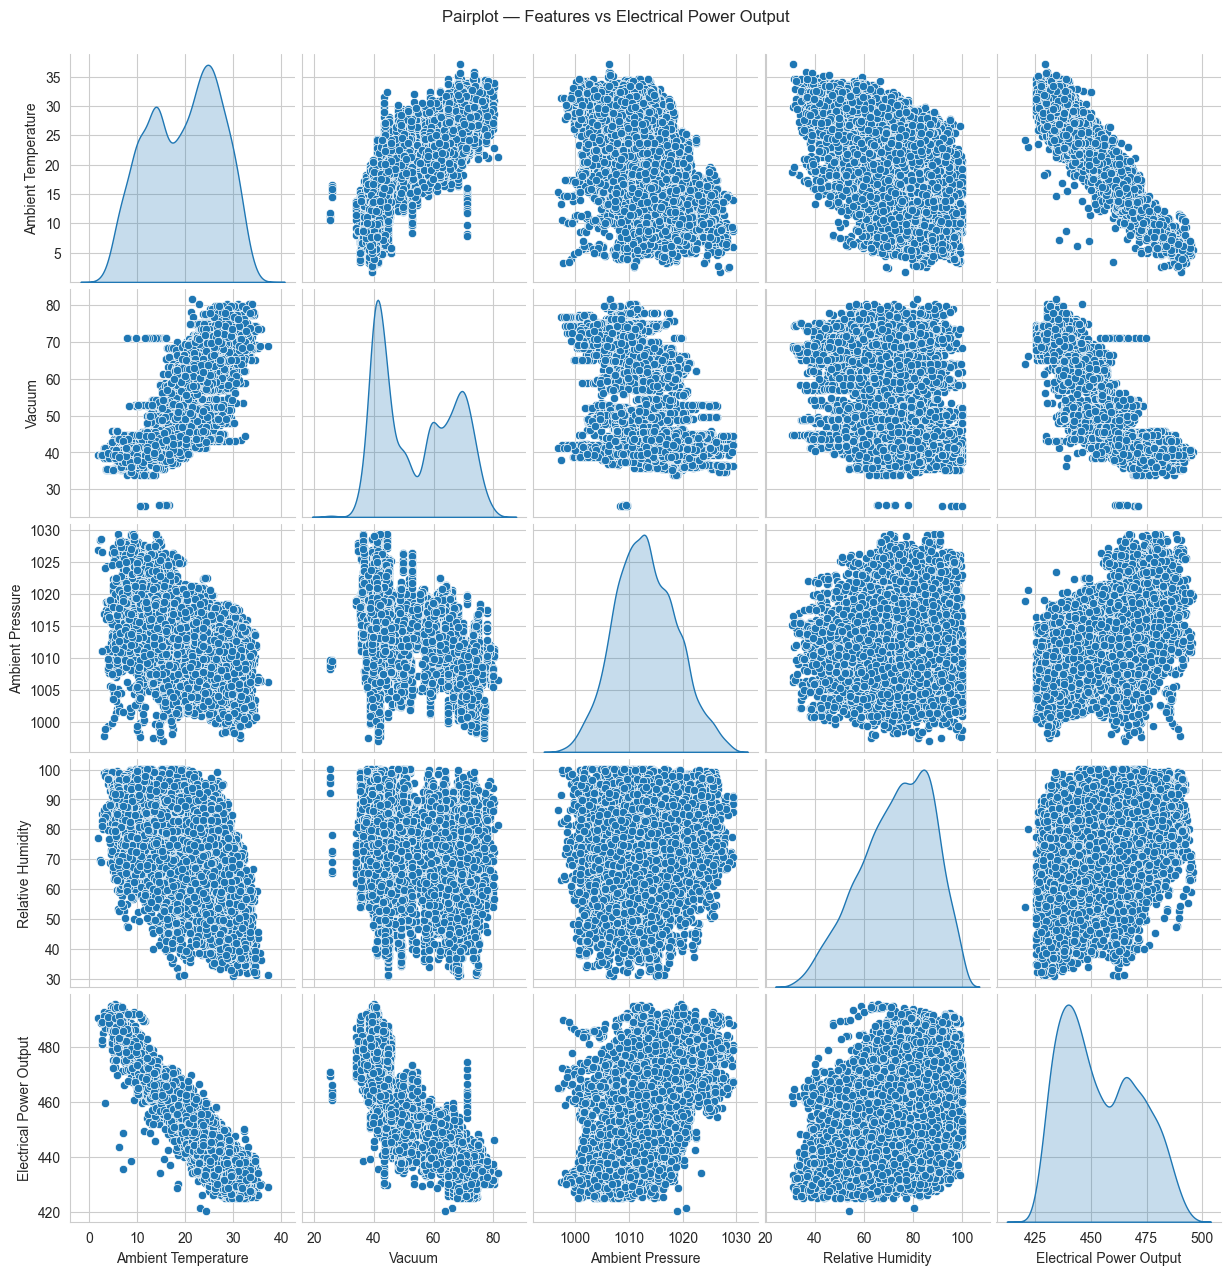

In [8]:
# Cell 4: Visualizations — all centered on Electrical Power Output

# 4.1 Distribution of Electrical Power Output
plt.figure(figsize=(7,5))
sns.histplot(df[target_col], kde=True, color="steelblue")
plt.title("Distribution of Electrical Power Output")
plt.xlabel("Electrical Power Output")
plt.show()

# 4.2 Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[feature_cols + [target_col]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Electrical Power Output")
plt.show()

# 4.3 Scatter plots: each feature vs Electrical Power Output
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.scatterplot(x=df[col], y=df[target_col], ax=axes[i], alpha=0.5, color="darkorange")
    axes[i].set_title(f"{col} vs Electrical Power Output")
plt.tight_layout()
plt.show()

# 4.4 Boxplot of Electrical Power Output
plt.figure(figsize=(5,5))
sns.boxplot(y=df[target_col], color="lightgreen")
plt.title("Boxplot of Electrical Power Output")
plt.show()

# 4.5 Pairplot with target
sns.pairplot(df[feature_cols + [target_col]], diag_kind="kde")
plt.suptitle("Pairplot — Features vs Electrical Power Output", y=1.02)
plt.show()

In [9]:
# Cell 5: Train-test split + feature scaling
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (7576, 4) X_test: (1894, 4)


In [10]:
# Cell 6: Train and compare models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print(results_df)

               Model  Train R2   Test R2  Train RMSE  Test RMSE  Train MAE  \
0            XGBoost  0.980325  0.963152    2.384433   3.290585   1.761706   
1      Random Forest  0.994769  0.962726    1.229518   3.309520   0.870788   
2  Gradient Boosting  0.952109  0.948207    3.720123   3.901227   2.836519   
3  Linear Regression  0.927543  0.930224    4.575850   4.528095   3.637742   
4              Ridge  0.927543  0.930222    4.575852   4.528186   3.637885   
5              Lasso  0.927541  0.930207    4.575892   4.528675   3.638095   

   Test MAE  
0  2.341257  
1  2.348127  
2  2.980918  
3  3.610207  
4  3.610424  
5  3.610859  


Best Model: XGBoost
Train R2: 0.9803 | Test R2: 0.9632
Train RMSE: 2.3844 | Test RMSE: 3.2906
Verdict: Good fit — train and test performance are close and reasonably high.


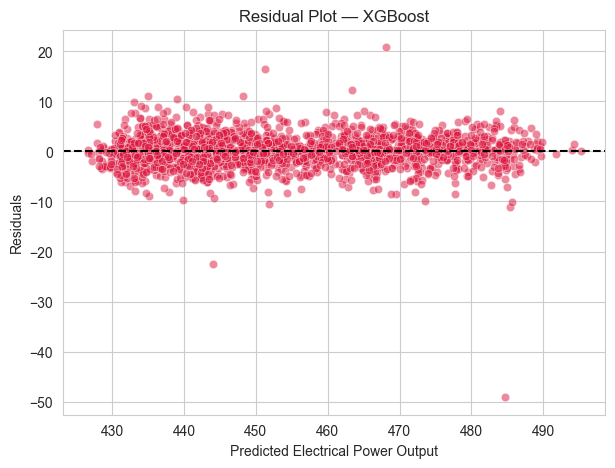

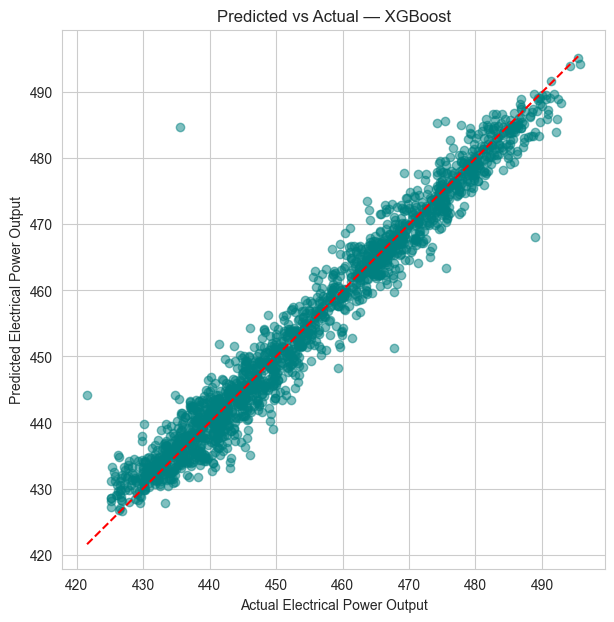

In [11]:
# Cell 7: Evaluate best model for overfitting/underfitting
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Best Model:", best_model_name)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

gap = train_r2 - test_r2
if gap > 0.1:
    verdict = "Overfitting — large gap between train and test performance."
elif train_r2 < 0.7 and test_r2 < 0.7:
    verdict = "Underfitting — model performs poorly on both train and test."
else:
    verdict = "Good fit — train and test performance are close and reasonably high."
print("Verdict:", verdict)

# Residual plot
residuals = y_test - y_test_pred
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5, color="crimson")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Electrical Power Output")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

# Predicted vs Actual plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, alpha=0.5, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Electrical Power Output")
plt.ylabel("Predicted Electrical Power Output")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

In [12]:
# Cell 8: Test best model on 5 random test rows
sample_idx = np.random.choice(range(len(X_test)), 5, replace=False)
sample_X = X_test[sample_idx]
sample_actual = y_test.values[sample_idx]
sample_pred = best_model.predict(sample_X)

comparison_df = pd.DataFrame({
    "Actual": sample_actual,
    "Predicted": sample_pred,
    "Error %": np.abs((sample_actual - sample_pred) / sample_actual) * 100
})
print(comparison_df)

   Actual   Predicted   Error %
0  466.63  463.945435  0.575309
1  447.44  442.510590  1.101692
2  447.24  441.891113  1.195977
3  435.75  441.504211  1.320530
4  481.77  481.442566  0.067965


In [13]:
# Cell 9: Manual input prediction
print("Enter values for the following features:")
at_val = float(input("Ambient Temperature: "))
v_val = float(input("Vacuum: "))
ap_val = float(input("Ambient Pressure: "))
rh_val = float(input("Relative Humidity: "))

manual_input = pd.DataFrame([[at_val, v_val, ap_val, rh_val]], columns=feature_cols)
manual_input_scaled = scaler.transform(manual_input)

predicted_output = best_model.predict(manual_input_scaled)
print(f"\nPredicted Electrical Power Output: {predicted_output[0]:.4f}")

Enter values for the following features:


Ambient Temperature:  13
Vacuum:  39
Ambient Pressure:  1016
Relative Humidity:  84



Predicted Electrical Power Output: 473.0065


In [14]:
# Cell 10: Save model and scaler
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved: best_model.pkl, scaler.pkl")

Saved: best_model.pkl, scaler.pkl
